In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# k means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [21]:
# customer segmeattaion & product segmentation 
df=pd.read_csv('Data/Mall_Customers.csv')

In [22]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [23]:
gender_id={
    'Male':0,
    'Female':1
}
df['Gender_id']=df['Gender'].map(gender_id)

In [24]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_id'],
      dtype='object')

In [25]:
x=df[['Age','Annual Income (k$)','Spending Score (1-100)','Gender_id']]

In [26]:
scalar=StandardScaler()
x_scale=scalar.fit_transform(x)

In [27]:
error_rate=[]
k_range=range(1,21)
for i in k_range:
    Kmeans=KMeans(n_clusters=i)
    Kmeans.fit_predict(x_scale)
    error_rate.append(Kmeans.inertia_)

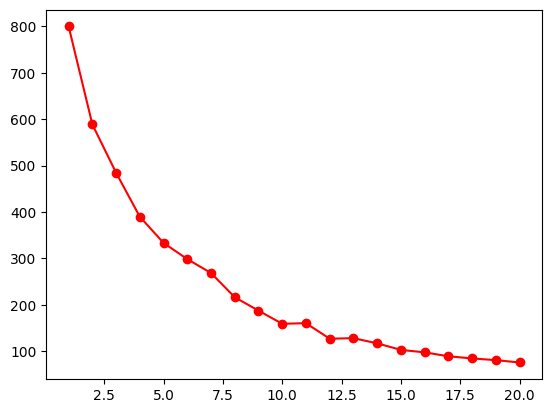

In [28]:
plt.plot(k_range,error_rate,c='red',marker='o')

In [ ]:
model=KMeans(n_clusters=5)
clusters=model.fit_predict(x_scale)


In [30]:
show_label=model.labels_


In [31]:
# accuracy for clstering
ss=silhouette_score(x_scale, show_label)
print(ss)

0.30979938197270623


In [32]:
df['clusters']=clusters
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_id,clusters
0,1,Male,19,15,39,0,4
1,2,Male,21,15,81,0,4
2,3,Female,20,16,6,1,1
3,4,Female,23,16,77,1,1
4,5,Female,31,17,40,1,1
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,3
196,197,Female,45,126,28,1,0
197,198,Male,32,126,74,0,3
198,199,Male,32,137,18,0,3


<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

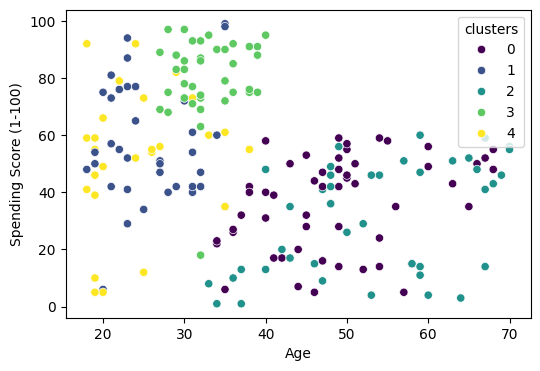

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x='Age', y='Spending Score (1-100)', hue='clusters',palette='viridis')